In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

rfm = pd.read_csv('data/rfm_segments.csv')

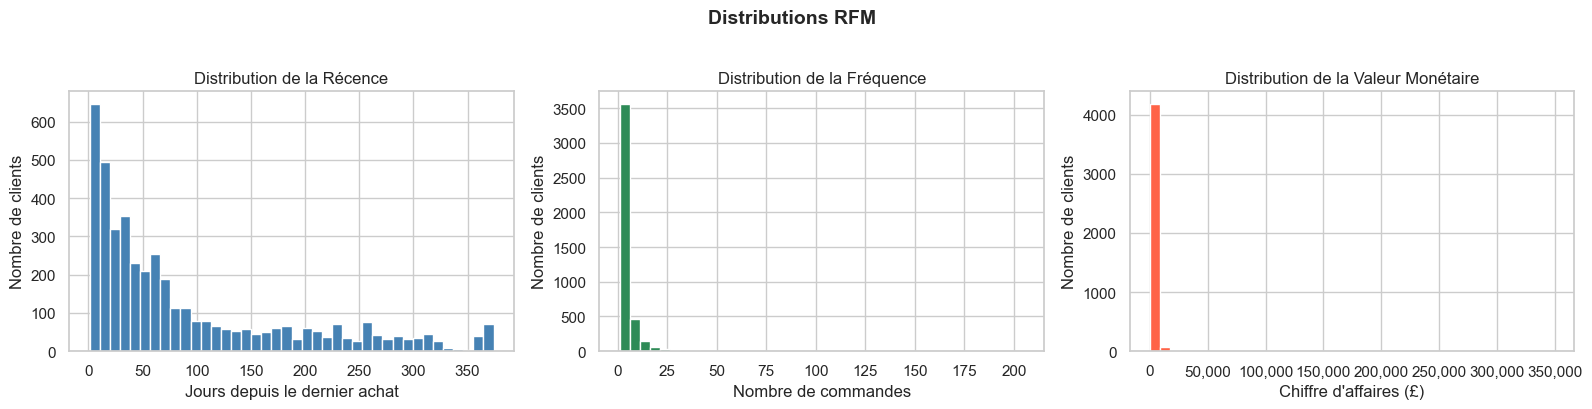

In [14]:
# --- Histogrammes : distributions de Récence, Fréquence et Valeur Monétaire ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(rfm['Recency'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de la Récence')
axes[0].set_xlabel('Jours depuis le dernier achat')
axes[0].set_ylabel('Nombre de clients')

axes[1].hist(rfm['Frequency'], bins=40, color='seagreen', edgecolor='white')
axes[1].set_title('Distribution de la Fréquence')
axes[1].set_xlabel('Nombre de commandes')
axes[1].set_ylabel('Nombre de clients')

axes[2].hist(rfm['Monetary'], bins=40, color='tomato', edgecolor='white')
axes[2].set_title('Distribution de la Valeur Monétaire')
axes[2].set_xlabel("Chiffre d'affaires (£)")
axes[2].set_ylabel('Nombre de clients')
axes[2].xaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

plt.suptitle('Distributions RFM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

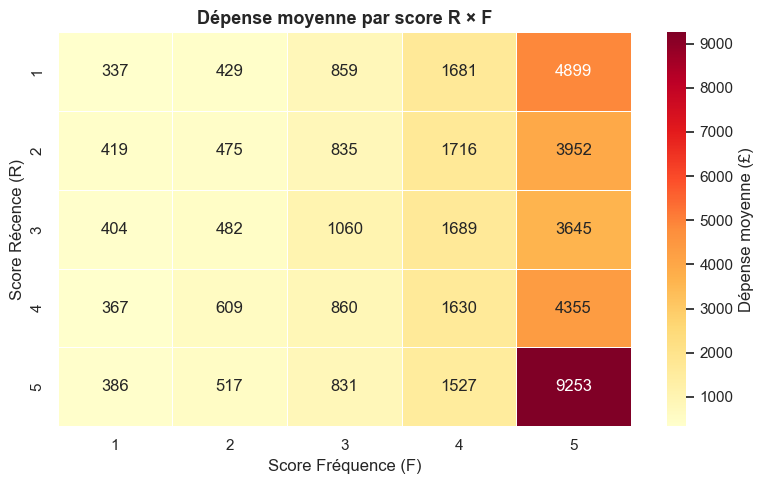

In [15]:
# --- Carte de chaleur : dépense moyenne selon les scores R et F ---
pivot = rfm.pivot_table(values='Monetary', index='R', columns='F', aggfunc='mean')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Dépense moyenne (£)'}
)
ax.set_title('Dépense moyenne par score R × F', fontsize=13, fontweight='bold')
ax.set_xlabel('Score Fréquence (F)')
ax.set_ylabel('Score Récence (R)')
plt.tight_layout()
plt.show()

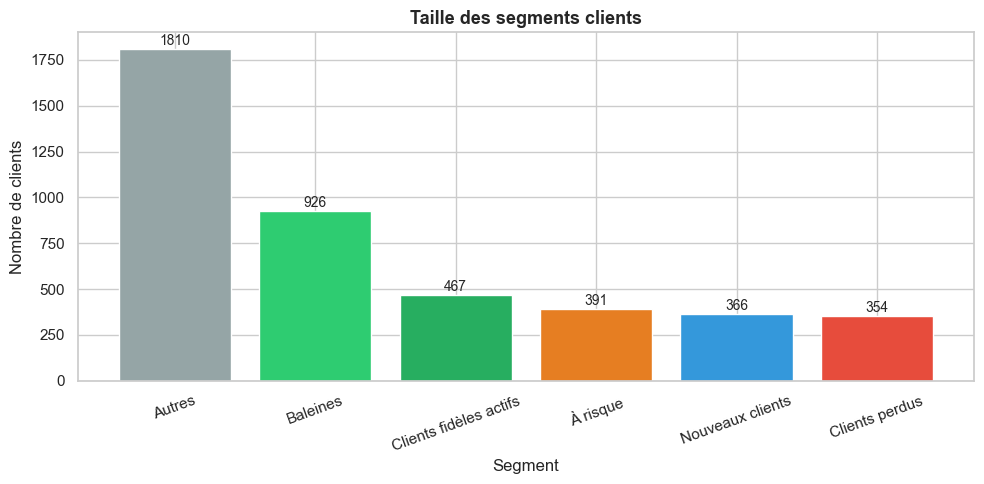

In [16]:
# --- Diagramme en barres : taille des segments ---
segment_counts = rfm['Segment'].value_counts().sort_values(ascending=False)

# Palette personnalisée pour identifier visuellement les segments clés
palette = {
    'Baleines':             '#2ecc71',
    'Clients fidèles actifs': '#27ae60',
    'Nouveaux clients':     '#3498db',
    'Autres':               '#95a5a6',
    'À risque':             '#e67e22',
    'Clients perdus':       '#e74c3c',
}
colors = [palette.get(s, '#bdc3c7') for s in segment_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(segment_counts.index, segment_counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, segment_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=10)

ax.set_title('Taille des segments clients', fontsize=13, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Nombre de clients')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

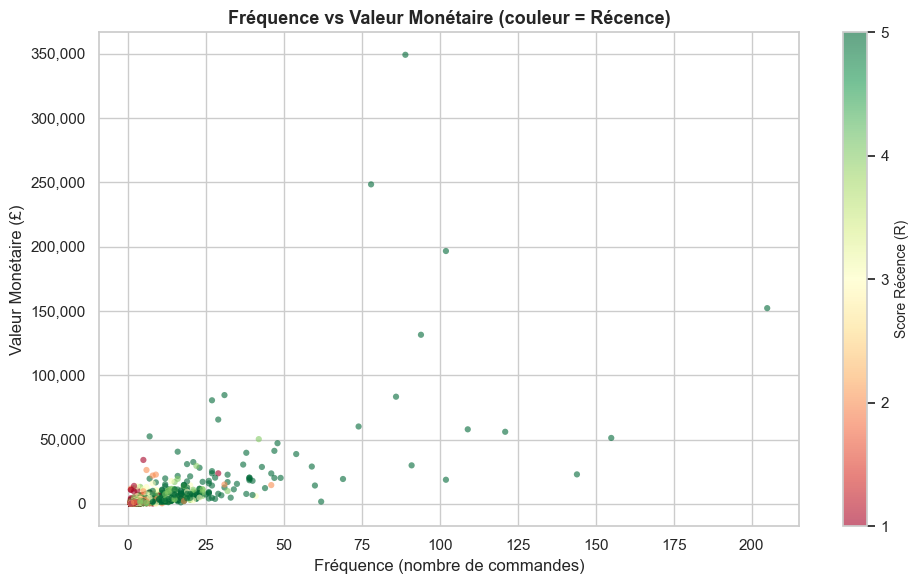

In [17]:
# --- Nuage de points : Fréquence vs Valeur Monétaire, coloré par Récence ---
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['R'],          # couleur = score de récence (1 = ancien, 5 = récent)
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='none',
    s=20
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Score Récence (R)', fontsize=10)
cbar.set_ticks([1, 2, 3, 4, 5])

ax.set_title('Fréquence vs Valeur Monétaire (couleur = Récence)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fréquence (nombre de commandes)')
ax.set_ylabel("Valeur Monétaire (£)")
ax.yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)
plt.tight_layout()
plt.show()

## Interprétation des résultats

### Baleines (R ≥ 4, F ≥ 4, M ≥ 4)
Clients les plus précieux : récents, acheteurs réguliers et gros dépensiers.
**Stratégie** : programme de fidélité premium, accès anticipé aux nouveautés, offres exclusives pour maintenir l'engagement et prévenir le churn.

### Nouveaux clients (R ≥ 4, F ≤ 2)
Ont acheté récemment mais peu souvent — fort potentiel de conversion.
**Stratégie** : séquences d'onboarding par e-mail, coupon sur le 2ᵉ achat, présentation de la gamme complète pour accélérer la répétition d'achat.

### Clients perdus (R ≤ 2, M ≥ 4)
Anciennement gros dépensiers, inactifs depuis longtemps — risque de perte définitive.
**Stratégie** : campagne de ré-engagement ciblée (offre « Vous nous manquez ! »), enquête de satisfaction pour comprendre le départ, remise exceptionnelle.

### Clients fidèles actifs (R ≥ 4, F ≥ 3)
Achètent régulièrement et sont récents, sans forcément dépenser le plus.
**Stratégie** : cross-sell et upsell, invitation au programme de parrainage, communication personnalisée pour augmenter le panier moyen.

### À risque (R ≤ 2, F ≥ 3)
Anciennement réguliers mais inactifs — signe d'insatisfaction ou de passage chez la concurrence.
**Stratégie** : alerte de ré-engagement précoce, offre de reconquête avant qu'ils basculent définitivement dans « Clients perdus ».